In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import typing
from numba import njit

In [2]:
def fun(vX):
    vY = 0.3 * vX **3 - vX **2 - 3
    return vY

In [3]:
vX = np.linspace(0, 5, 31)
hF = lambda x: fun(x)
vY = hF(vX)

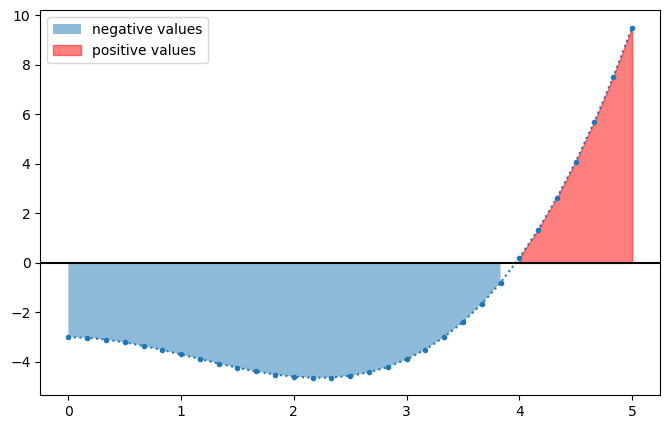

In [32]:
hF, hA = plt.subplots(figsize=(8,5))
hA.plot(vX, vY, ':', marker='o', markersize=3 )
hA.axhline(color='k')
hA.fill_between(vX, vY, 0, where=vY < 0, alpha=0.5, label='negative values')
hA.fill_between(vX, vY, 0, where=vY > 0, alpha=0.5, color = 'red', label='positive values')
plt.legend()
plt.show()

In [5]:
def sign(val):
    val = float(val)
    return (val > 0) - (val < 0)

In [6]:
sign(0)

0

In [18]:
#@njit
def BisectRootSolve(hF, valA, valB, numIter=1_000, xtol=10 ** (-6)):

    for i in range(numIter):
        valC = (valA + valB) / 2
        if (sign(hF(valA)) != sign(hF(valB))) and ((valB - valA) < xtol):
            return valC
        
        elif sign(hF(valA)) != sign(hF(valC)):
            valB = valC
        elif sign(hF(valB)) != sign(hF(valC)):
            valA = valC
    return valC

In [37]:
root = BisectRootSolve(fun, vX[0], vX[-1])

In [38]:
root

np.float64(3.9683446288108826)

In [41]:
hF = lambda x: fun(x)
sp.integrate.quad(hF, valA, root )[0]

-14.136485223420769

In [44]:
sp.integrate.simpson(hF(x = np.linspace(0, root, 31)), x = np.linspace(0, root, 31))

np.float64(-14.136485223420769)

In [46]:
from scipy.interpolate import PchipInterpolator
i_model = PchipInterpolator(vX, hF(vX))
y_hat = i_model(x=3)
y_hat

array(-3.9)